In [42]:
import pandas as pd
import matplotlib.pyplot as plt     
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

In [ ]:
df = pd.read_csv(r"D:\DEPI R4 ML\Data Sets\Life-Expectancy-Data-Averaged (1).csv")
df.head()

,Country,Region,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,Polio,Diphtheria,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling,Economy_status,Life_expectancy
0,Afghanistan,Asia,2007.5,71.08125,98.61250,265.804969,0.016125,64.5625,24.3750,22.46250,55.3750,55.1250,0.022500,408.5625,27.450625,16.58125,15.58125,2.90000,1.0,59.65625
1,Albania,Rest of Europe,2007.5,15.25625,17.14375,83.132969,4.696875,98.0000,95.9375,25.85625,98.1250,98.0625,0.025625,3071.1250,2.969375,1.61875,1.70000,9.24375,1.0,75.95000
2,Algeria,Africa,2007.5,26.75625,31.19375,113.439281,0.400625,88.3125,93.2500,24.86875,91.7500,91.8750,0.021875,3745.1250,34.820625,6.09375,5.97500,6.99375,1.0,73.78750
3,Angola,Africa,2007.5,88.76875,144.16250,297.844063,4.935625,68.8125,64.0000,22.51875,35.7500,55.5625,1.303750,2647.8125,21.623750,6.19375,6.66875,4.60625,1.0,52.82500
4,Antigua and Barbuda,Central America and Caribbean,2007.5,9.47500,11.51875,142.478813,7.755000,98.2500,75.4375,25.85000,96.9375,98.3125,0.125000,14678.7500,0.085000,3.42500,3.37500,9.01875,1.0,75.35000


: 

In [ ]:
df.isnull().sum()

Country                        0
Region                         0
Year                           0
Infant_deaths                  0
Under_five_deaths              0
Adult_mortality                0
Alcohol_consumption            0
Hepatitis_B                    0
Measles                        0
BMI                            0
Polio                          0
Diphtheria                     0
Incidents_HIV                  0
GDP_per_capita                 0
Population_mln                 0
Thinness_ten_nineteen_years    0
Thinness_five_nine_years       0
Schooling                      0
Economy_status                 0
Life_expectancy                0
dtype: int64

: 

In [ ]:
cat_cols = df.select_dtypes(include=["object"]).columns

print(cat_cols)

Index(['Country', 'Region'], dtype='object')


: 

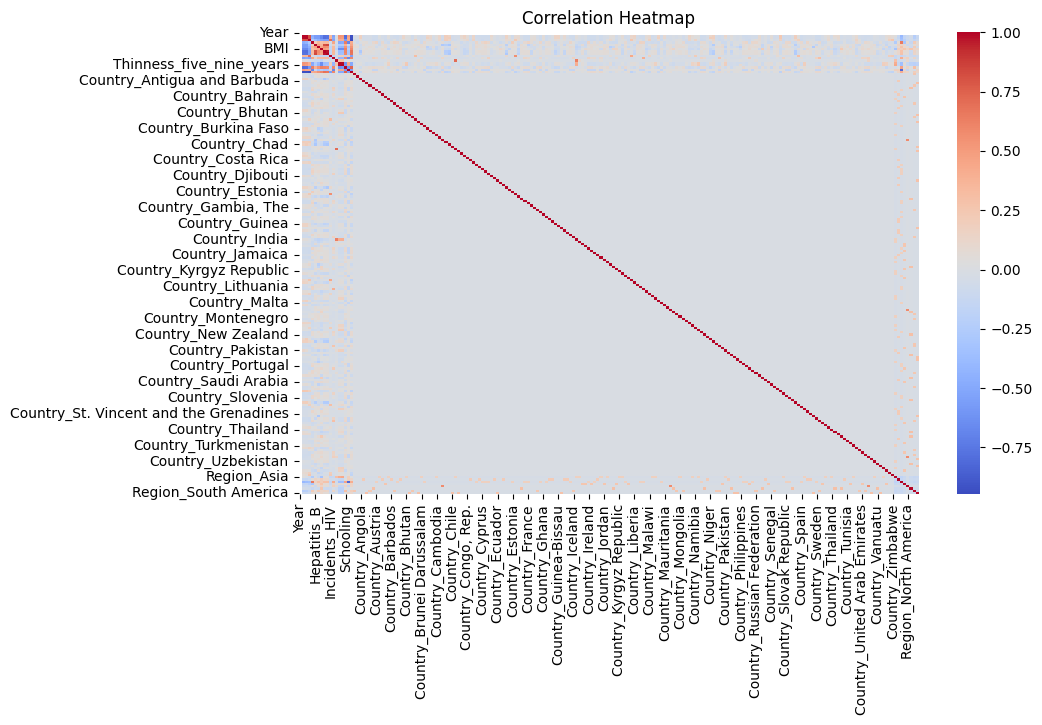

: 

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
df["Health_index"] = df["BMI"] + df["Incidents_HIV"]
df["Disease_load"] = df["Incidents_HIV"] + df["Measles"] + df["Infant_deaths"]
df["Economy"] = df["GDP_per_capita"] + df["Schooling"]

: 

In [43]:
X = df.drop("Life_expectancy", axis=1)
y = df["Life_expectancy"]

In [44]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [49]:
y_class = pd.cut(y, bins=3, labels=[0,1,2])

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [51]:
ada = AdaBoostRegressor(n_estimators=100)
ada.fit(X_train, y_train)

y_pred_ada = ada.predict(X_test)

In [52]:
gb = GradientBoostingRegressor(n_estimators=100)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

In [53]:
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [56]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("AdaBoost MSE:", mean_squared_error(y_test, y_pred_ada))
print("AdaBoost MAE:", mean_absolute_error(y_test, y_pred_ada))
print("AdaBoost R² Score:", r2_score(y_test, y_pred_ada))

print("\nGradient Boosting MSE:", mean_squared_error(y_test, y_pred_gb))
print("Gradient Boosting MAE:", mean_absolute_error(y_test, y_pred_gb))
print("Gradient Boosting R² Score:", r2_score(y_test, y_pred_gb))

print("\nXGBoost MSE:", mean_squared_error(y_test, y_pred_xgb))
print("XGBoost MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("XGBoost R² Score:", r2_score(y_test, y_pred_xgb))

AdaBoost MSE: 2.4453220822043233
AdaBoost MAE: 1.2313775456525218
AdaBoost R² Score: 0.9727659810567995

Gradient Boosting MSE: 1.4191298880422205
Gradient Boosting MAE: 0.9923530386498691
Gradient Boosting R² Score: 0.984194879465954

XGBoost MSE: 3.1060519067041854
XGBoost MAE: 1.4058478037516275
XGBoost R² Score: 0.96540730684054
